# Homework 7
## By Ram Kakinada
## ECE 580C7

In [2]:
#HW 07: phase retrieval
# Starter code by Jesse Wilson (2024) jesse.wilson@colostate.edu
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torchvision.transforms.functional import gaussian_blur
import numpy as np
from random import randint

/top/students/UNGRAD/ECE/ramk/home/pytorch-linuxg4/lib64/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### This portion of the code is farily straightforward as we are importing the necessary libraries in order to do our computations. Going thruough the list of libraires, torch is necessary for setting our enviornemnt where we can interact with the tensors and set up our GPU. Torchvision allows to import some built in libraries like MNIST and CIFAR while also allowing us to develop the building blocks of a CNN. Matplotlib allows us to plot graphs. The rest of the libraries are derivatives of these libraries or standard built in python libraries. 

In [3]:
# use this for Pytorch version 1.7.1 on ETS servers
from torch.fft import fftn, ifftn

def fft2(x):
    return fftn(x,dim=(2,3))

def ifft2(x):
    return ifftn(x,dim=(2,3))

def fftshift(x):
    nbatch, nchan, ny, nx = x.shape
    x = torch.roll(x, ny//2, 2)
    x = torch.roll(x, nx//2, 3)
    return x

def ifftshift(x):
    nbatch, nchan, ny, nx = x.shape
    x = torch.roll(x, -1*ny//2, 2)
    x = torch.roll(x, -1*nx//2, 3)
    return x

#### This is just defining some standard FFT functions where fft2 defnies a standard 2 dimensional fft, ifft2 defines the inverse fast fourier transform, fft shift deifnes the shift of the zero frequecny. In this case it is shifted by half the spectrum to arrange the data more intuitively, finally the ifftshift does the inversre frequecny shift to arrange the frequencies accrding to how they orignially were. 

In [4]:
device = torch.device('cuda:1')

#### Assigns the computation deivice to the second Nvidia GPU it finds

In [8]:
# load the usual suspects
transform = transforms.Compose([
    transforms.ToTensor()])
dataset_train = datasets.MNIST(root='data',train=True,download=True,transform=transform)
dataset_val = datasets.MNIST(root='data',train=False,download=True)


#### Load in the MNIST database for handwritten numbers

In [23]:
def createAperture( radius ):
    x=np.linspace(1,64,64)-32
    y=np.linspace(1,64,64)-32
    X,Y = np.meshgrid(x,y)
    
    aperture = X**2+Y**2 <= radius**2
    return aperture

def createPhaseObject( img, aperture ):
    # set up a complex object in which the image is encoded with phase
    # and is surrounded by an opaque aperture
    nbatch = img.shape[0]
    obj = torch.zeros(nbatch,64,64,dtype=torch.cfloat) # complex object
    pad_amount = 18
    obj = torch.exp( 3.14j/4*F.pad(img, (pad_amount,pad_amount,pad_amount,pad_amount)))
    obj = obj * aperture

    return obj


#### This first function creates an artifical aperture. The aperture in this case is a circle of some arbitrary radius which is just an indicator 2 dimnesional matrix that is either true or false. By creating an aritificial apreture you can make an incoherent light source into a coherent source. With a coherent source you can extract a coherent spread function which preserves phase information significantly better than a point spread function which allows you to then apply techniques like holography. The createPhaseObject creates a complex phase representation of the objects based off of the orignial image and the aperture being used. The only reason a realistic and accurate phase model can be created of the object is because of the aperture for the previously mentioned reasons.

In [24]:
def forwardModel( obj ):
    # calculate a diffraction patern of a complex object using the Fourier transform
    diffr_complex = fftshift(fft2(ifftshift(obj)))
    
    diffr_phase = diffr_complex.angle() # phase of diffraction patern (not measurable)
    diffr_abs = diffr_complex.abs()   # amplitude of diffraction pattern (seen by imaging sensor)

    return( diffr_abs, diffr_phase )

#### The function above represents the diffraction pattern that was extracted fromt the phase object.

In [25]:
# 64x64 encoder decoder network
# uses strided convs instead of conv->maxpool
# uses strided transposed convs instead of upsampling -> conv

nFilt = 32
enc = nn.Sequential(
    nn.Conv2d(1,nFilt,kernel_size=3,stride=2), # 64x64 -> 31x31
    nn.LeakyReLU(),
    nn.Conv2d(nFilt,nFilt,kernel_size=3,stride=2), # 31x31 -> 15x15
    nn.LeakyReLU(),
    nn.Conv2d(nFilt,nFilt,kernel_size=3,stride=2), # 15x15 -> 7x7
    nn.LeakyReLU(),
    nn.Conv2d(nFilt,nFilt,kernel_size=3,stride=2), # 7x7 -> 3x3
    nn.LeakyReLU()
)

dec = nn.Sequential(
    nn.ConvTranspose2d(nFilt,nFilt,kernel_size=3,stride=2), # 3x3 -> 7x7
    nn.LeakyReLU(),
    nn.ConvTranspose2d(nFilt,nFilt,kernel_size=3,stride=2), # 7x7 -> 15x15
    nn.LeakyReLU(),
    nn.ConvTranspose2d(nFilt,nFilt,kernel_size=3,stride=2), # 15x15 -> 31x31
    nn.LeakyReLU(),
    nn.ConvTranspose2d(nFilt,1,kernel_size=3,stride=2,output_padding=1), # 15x15 -> 64x64
)

net = nn.Sequential(enc,dec).to(device)

#### This block just defines the convoltuional blocks for the encoder and the decoder. The activation function is a leaky ReLu in order to account for some of the non linearity in the noise. 

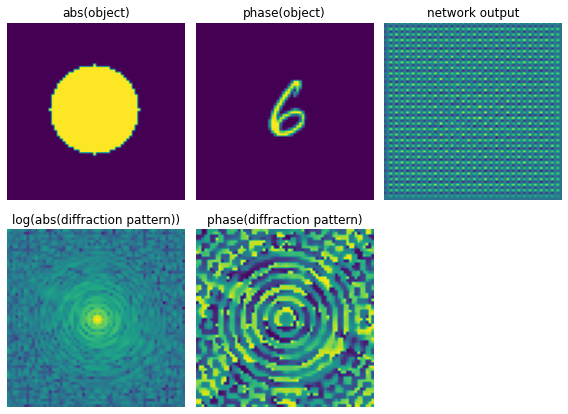

In [9]:
# quick test: generate a random object, diffraction pattern, and pass through network
ind = randint(0,len(dataset_train)-1)
img = dataset_train[ind][0].unsqueeze(0).to(device)

aperture = createAperture(16)
aperture = torch.Tensor(aperture).to(device)

obj_complex = createPhaseObject(img, aperture)
diffr_abs, diffr_phase  = forwardModel(obj_complex)

obj_phase_est = net(diffr_abs)

# plot the results
plt.figure(figsize=(8,6))

plt.subplot(231)
plt.imshow(obj_complex.abs().cpu().squeeze())
plt.axis('off')
plt.title('abs(object)')

plt.subplot(232)
plt.imshow(obj_complex.angle().cpu().squeeze())
plt.axis('off')
plt.title('phase(object)')

plt.subplot(233)
plt.imshow(obj_phase_est.detach().cpu().squeeze())
plt.axis('off')
plt.title('network output')

plt.subplot(234)
plt.imshow(np.log(diffr_abs.cpu().squeeze()))
plt.axis('off')
plt.title('log(abs(diffraction pattern))')

plt.subplot(235)
plt.imshow(diffr_phase.cpu().squeeze())
plt.axis('off')
plt.title('phase(diffraction pattern)')

plt.tight_layout()
plt.show()

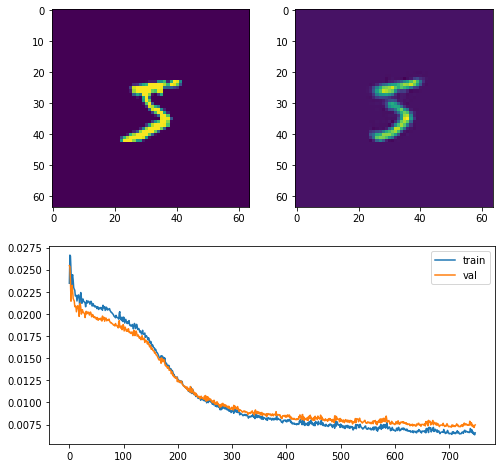

In [27]:
# APPROACH 1: directly estimate object's phase (real space)
net = nn.Sequential(enc,dec).to(device) # reset the network
optimizer = torch.optim.Adam(net.parameters(), lr=0.003)
loss_fn = nn.L1Loss()

# load a limited set of the training data onto the GPU
nTrain = 5000
y = dataset_train.data.unsqueeze(1).float().to(device)/255.
y= y[0:nTrain]

# calculate complex objects
aperture = createAperture(16)
aperture = torch.Tensor(aperture).to(device)

obj = createPhaseObject( y, aperture )
diffr_abs, diffr_phase = forwardModel(obj)

# load entire validation set onto the GPU
y_val = dataset_val.data.unsqueeze(1).float().to(device)/255.
y_val = y_val[0:nTrain]
obj_val = createPhaseObject( y_val, aperture )
diffr_abs_val, diffr_phase_val = forwardModel(obj_val)

loss_train_vec = []
loss_val_vec = []

# training loop
n_epochs = 750
for epoch in range(1,n_epochs):
    obj_phase_est = net(diffr_abs)

    loss = loss_fn(obj_phase_est,obj.angle())
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
    # calculate validation loss
    with torch.no_grad():
        obj_phase_est_val = net(diffr_abs_val)
        loss_val = loss_fn(obj_phase_est_val, obj_val.angle())
        
    loss_val_vec   += [loss_val.item()]
    
    # plot training/validation loss curves
    clear_output(wait=True)
    plt.figure(figsize=[8,8])
    plt.subplot(221)
    plt.imshow(obj[0].angle().cpu().squeeze())
    plt.subplot(222)
    plt.imshow(obj_phase_est[0].detach().cpu().squeeze())
    plt.subplot(212)
    plt.plot(loss_train_vec)
    plt.plot(loss_val_vec)
    plt.legend(['train','val'])
    plt.show()
    

#### This first approach is taking a look at modeling the diffraction pattern by directly estimating it from real values sapce as opposed to taking a look from the fourier space.  The noisy data is produced by passing a gaussian filter over the image which adds a radnom phase and amplitude to the data. 

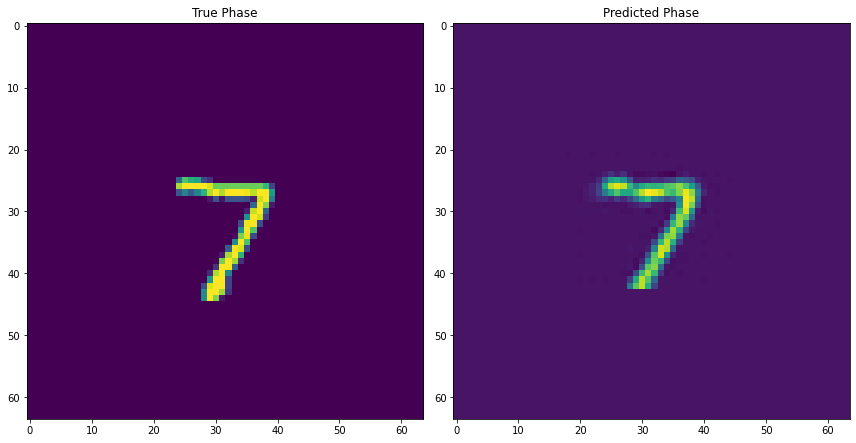

In [31]:
# YOUR CODE HERE TO EVALUATE RESULTS ON SOME VALIDATION DATA

with torch.no_grad():
    obj_phase_est_val = net(diffr_abs_val)
    true_phase_val = obj_val.angle() 


plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.imshow(true_phase_val[0].cpu().squeeze())
plt.title('True Phase')

plt.subplot(122)
plt.imshow(obj_phase_est_val[0].detach().cpu().squeeze())
plt.title('Predicted Phase')

plt.tight_layout()
plt.show()


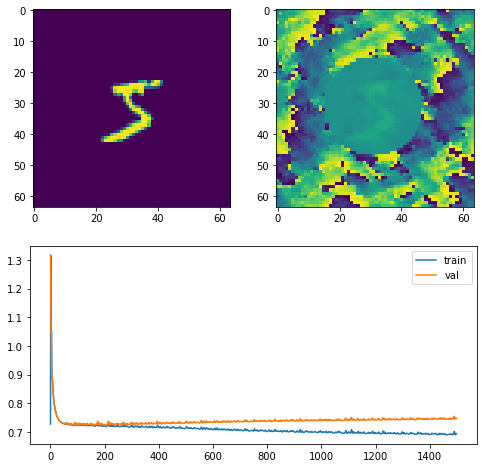

In [12]:
# TRAINING LOOP TO PREDICT k-SPACE PHASE
net = nn.Sequential(enc,dec).to(device) # reset the network

optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
loss_fn = nn.L1Loss()

# load a limited set of the training data onto the GPU
nTrain = 5000
y = dataset_train.data.unsqueeze(1).float().to(device)/255.
y= y[0:nTrain]

# calculate complex objects
aperture = createAperture(16)
aperture = torch.Tensor(aperture).to(device)

obj = createPhaseObject( y, aperture )
diffr_abs, diffr_phase = forwardModel(obj)

# load entire validation set onto the GPU
y_val = dataset_val.data.unsqueeze(1).float().to(device)/255.
y_val = y_val[0:nTrain]
obj_val = createPhaseObject( y_val, aperture )
diffr_val_abs, diffr_val_phase = forwardModel(obj_val)

loss_train_vec = []
loss_val_vec = []

# training loop
n_epochs = 1500
for epoch in range(1,n_epochs):
    diffr_phase_est = net(diffr_abs)

    loss = loss_fn(diffr_phase_est,diffr_phase)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
    # calculate validation loss
    with torch.no_grad():
        diffr_phase_est_val = net(diffr_val_abs)
        loss_val = loss_fn(diffr_phase_est_val, diffr_phase)
        
    loss_val_vec   += [loss_val.item()]
    
    # inverse transform the estimated complex diffraction pattern to estimate the complex object
    #diffr_est = diffr_abs*torch.exp(1j*diffr_phase_est)
    diffr_est=diffr_abs*torch.complex( torch.cos(diffr_phase_est) , torch.sin(diffr_phase_est) )
    obj_est = fftshift(ifft2(ifftshift(diffr_est)))
    
    
    clear_output(wait=True)
    plt.figure(figsize=[8,8])
    plt.subplot(221)
    plt.imshow(obj[0].angle().cpu().squeeze())
    plt.subplot(222)
    plt.imshow(obj_est[0].angle().detach().cpu().squeeze())
    plt.subplot(212)
    plt.plot(loss_train_vec)
    plt.plot(loss_val_vec)
    plt.legend(['train','val'])
    plt.show()
    

#### This function takes a look at the diffraction patter from the fourier space and does the comparisons in the frequecny space instead. The noisy data is produced by passing a gaussian filter over the image which adds a radnom phase and amplitude to the data. 

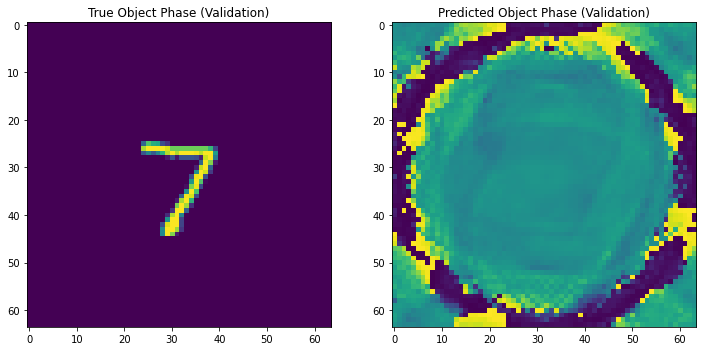

In [32]:
# YOUR CODE HERE TO EVALUATE RESULTS ON SOME VALIDATION DATA
# hint: in making images of phase with plt.imshow(), you may need to adjust vmin and vmax 
#       to keep the large phase in undefined regions from washing out the signal of interest
# YOUR CODE TO EVALUATE RESULTS ON SOME VALIDATION DATA

with torch.no_grad():
    diffr_phase_est_val = net(diffr_val_abs)


diffr_est_val = diffr_val_abs * torch.complex(torch.cos(diffr_phase_est_val), torch.sin(diffr_phase_est_val))


obj_est_val = fftshift(ifft2(ifftshift(diffr_est_val)))

plt.figure(figsize=[12, 6])

plt.subplot(121)
plt.title('True Object Phase (Validation)')
plt.imshow(obj_val[0].angle().cpu().squeeze())

plt.subplot(122)
plt.title('Predicted Object Phase (Validation)')
plt.imshow(obj_est_val[0].angle().cpu().squeeze())

plt.show()

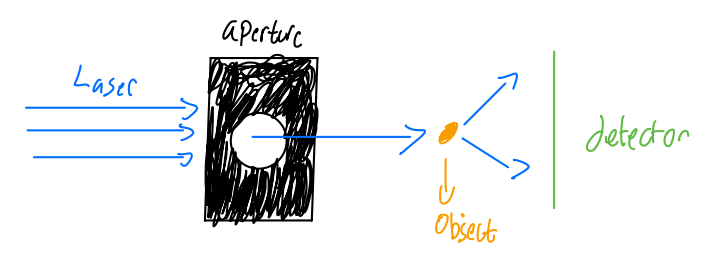
#### Figure 1: Hand drawn sketch of physcial model with detector source, object, and aperture

### Task 2
#### The first approach works significantly better than the seecond approach. This can be seen both visually and in the error plots as the error of the validation sets  in the first approach is significantly lower than in the second approach. In terms of wether an encoder decoder can accurately map between the fourier and real representation of the diffraction pattern, it is possible but quite hard to do becuase you are looking for two different representations of the image and you are also looking for vastly different pattern in the frequency domain data than you are in the real image data. The Fourier transform is highly sensitive to changes in phase information. Your nertwork could get a really close approximation of the fourier domain of the original image, but unless the error is essentially zero the frequency space, those small differences and erros will lead to an unrecognizable final result in the spatial domain. I am not sure if it can be said that the phase is well defined but more that the information at that phase does not contribute to the image therefore it might be better to say it is unknown. The loss values between the two approaches are not at all comaprible as the loss on the second appraoch is orders of magnitude higher. 

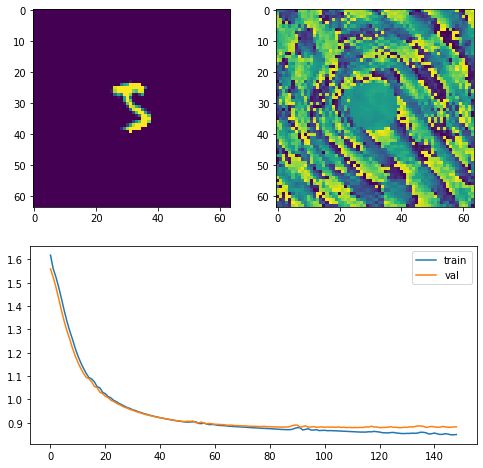

In [35]:
# Task # Improvements
# TRAINING LOOP TO PREDICT k-SPACE PHASE
net = nn.Sequential(enc,dec).to(device) # reset the network

optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
loss_fn = nn.L1Loss()

# load a limited set of the training data onto the GPU
nTrain = 5000
y = dataset_train.data.unsqueeze(1).float().to(device)/255.
y= y[0:nTrain]

# calculate complex objects
aperture = createAperture(8)
aperture = torch.Tensor(aperture).to(device)

obj = createPhaseObject( y, aperture )
diffr_abs, diffr_phase = forwardModel(obj)

# load entire validation set onto the GPU
y_val = dataset_val.data.unsqueeze(1).float().to(device)/255.
y_val = y_val[0:nTrain]
obj_val = createPhaseObject( y_val, aperture )
diffr_val_abs, diffr_val_phase = forwardModel(obj_val)

loss_train_vec = []
loss_val_vec = []

# training loop
n_epochs = 150
for epoch in range(1,n_epochs):
    diffr_phase_est = net(diffr_abs)

    loss = loss_fn(diffr_phase_est,diffr_phase)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
    # calculate validation loss
    with torch.no_grad():
        diffr_phase_est_val = net(diffr_val_abs)
        loss_val = loss_fn(diffr_phase_est_val, diffr_phase)
        
    loss_val_vec   += [loss_val.item()]
    
    # inverse transform the estimated complex diffraction pattern to estimate the complex object
    #diffr_est = diffr_abs*torch.exp(1j*diffr_phase_est)
    diffr_est=diffr_abs*torch.complex( torch.cos(diffr_phase_est) , torch.sin(diffr_phase_est) )
    obj_est = fftshift(ifft2(ifftshift(diffr_est)))
    
    
    clear_output(wait=True)
    plt.figure(figsize=[8,8])
    plt.subplot(221)
    plt.imshow(obj[0].angle().cpu().squeeze())
    plt.subplot(222)
    plt.imshow(obj_est[0].angle().detach().cpu().squeeze())
    plt.subplot(212)
    plt.plot(loss_train_vec)
    plt.plot(loss_val_vec)
    plt.legend(['train','val'])
    plt.show()
    

### Task 3
#### Hypothesis: If we reduce the aperture radius than there is less unesccary nosie that gets into the model which will make it easier for the second appraoch to acutally find the diffraction pattern. Result: This was not the case at all as the model in fact performed slighty worse which is puzzeling. For fun I also tried to increase the aperture radius but again found that ther performance was worse and for some reason 16 was a sweet spot. For some reason a radius of 16 was just the right amount of light/data that was allowed in.

#### Hypothesis 2: Prevent overfititing will result in marignally better result. In this task I noticed that the second approach was overfitting as you pushed the algorithim  to run more epochs so I beleive that reducing the number of epochs will result in a marignally better performance of the model. 